<center><span style="color:#336699">
CAP-394-3 - Introdução à Ciência de Dados</span></center>
<hr style="border:2px solid #0077b9;">

<br/>

<div style="text-align: center;font-size: 200%;">
<strong>Comparação de Foundation model com algoritmos do estado da arte para dados de observação da terra</strong>
 <br/>
</div>


<br/>

<div style="text-align: center;font-size: 90%;">
    Carla Aparecida de Almeida Paula e Sofia Sena Tavares  <sup><a href=""></i></a></sup>
    <br/><br/>
     Instituto Nacional de Pesquisas Espaciais (INPE)
    <br/>
    Avenida dos Astronautas, 1758, Jardim da Granja, São José dos Campos, SP 12227-010, Brasil
    <br/><br/>
    Atualização: 6 de agosto de 2026
</div>

<br/>

<div style="text-align: justify;  margin-left: 25%; margin-right: 25%;">
    <b>Resumo.</b> Essa etapa tem por objetivo o treinamento de modelos e métricas.
</div>

<br/>

<center><span style="color:#336699; font-size: 100%;">
1. Importando as Bibliotecas</span></center>
<hr style="border:1px solid #0077b9;">

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil
import os

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

<center><span style="color:#336699; font-size: 100%;">
3. Importando os modelos</span></center>
<hr style="border:1px solid #0077b9;">

In [3]:
!pip install catboost
!pip install tabpfn
!pip install tabfm
!pip install tabicl

In [4]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from tabpfn import TabPFNClassifier
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0
from tabfm import TabFMClassifier
from tabicl import TabICLClassifier

<center><span style="color:#336699; font-size: 100%;">
4. Importando as amostras</span></center>
<hr style="border:1px solid #0077b9;">

In [5]:
df = pd.read_csv('dataset_stac_aws_deter_floresta.csv')
print(df.columns)

Index(['longitude', 'latitude', 'label', 'red_mean', 'red_std', 'red_min',
       'red_max', 'red_p10', 'red_p90', 'red_amp', 'nir_mean', 'nir_std',
       'nir_min', 'nir_max', 'nir_p10', 'nir_p90', 'nir_amp', 'ndvi_mean',
       'ndvi_std', 'ndvi_min', 'ndvi_max', 'ndvi_p10', 'ndvi_p90', 'ndvi_amp'],
      dtype='object')


In [6]:
#verificar classes
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))

label
Disturbio          100
Floresta_Nativa    100
Name: count, dtype: int64
label
Disturbio          0.5
Floresta_Nativa    0.5
Name: proportion, dtype: float64


<center><span style="color:#336699; font-size: 100%;">
5. Separação das amostras</span></center>
<hr style="border:1px solid #0077b9;">

In [7]:
#definir x e y
features = [
    'red_mean', 'red_std', 'red_min', 'red_max', 'red_p10', 'red_p90', 'red_amp',
    'nir_mean', 'nir_std', 'nir_min', 'nir_max', 'nir_p10', 'nir_p90', 'nir_amp',
    'ndvi_mean', 'ndvi_std', 'ndvi_min', 'ndvi_max', 'ndvi_p10', 'ndvi_p90', 'ndvi_amp'
]

X = df[features]
y = df['label']

# Codificação do rótulo para ficar idêntico ao XGBoost/Random Forest/LightGBM/CatBoost
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Codificar o rótulo para numérico (0 e 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [8]:
# Divisão 70% Treino e 30% Teste (mesma semente 42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

In [9]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Classes:", le.classes_)

X_train: (140, 21)
X_test: (60, 21)
Classes: ['Disturbio' 'Floresta_Nativa']


In [10]:
# Processo atual
processo = psutil.Process(os.getpid())

# Dicionários para armazenar os resultados
predicoes = {}
probabilidades = {}
tempos_ajuste = {}
tempos_inferencia = {}
memorias = {}

<center><span style="color:#336699; font-size: 100%;">
6. Foundation Models</span></center>
<hr style="border:1px solid #0077b9;">

TabPFN

In [11]:
# Treinamento do TabPFN (Foundation Model)
tabpfn_model = TabPFNClassifier(model_path='tabpfn-v2-classifier.ckpt', device='cpu')

# Memória antes do ajuste
memoria_antes = processo.memory_info().rss / (1024 ** 2)
# Medir tempo de ajuste
inicio = time.perf_counter()

tabpfn_model.fit(X_train, y_train)

fim = time.perf_counter()

tempo_ajuste_tabpfn = fim - inicio

memoria_depois = processo.memory_info().rss / (1024 ** 2)
memoria_tabpfn = memoria_depois - memoria_antes

#inferencia
inicio = time.perf_counter()

pred_tabpfn = tabpfn_model.predict(X_test)
prob_tabpfn = tabpfn_model.predict_proba(X_test)

fim = time.perf_counter()

tempo_infer_tabpfn = fim - inicio


#Armazenar avaliações
predicoes["TabPFN"] = pred_tabpfn

probabilidades["TabPFN"] = prob_tabpfn

tempos_ajuste["TabPFN"] = tempo_ajuste_tabpfn

tempos_inferencia["TabPFN"] = tempo_infer_tabpfn

memorias["TabPFN"] = memoria_tabpfn
##--
print(f"Tempo de ajuste:      {tempo_ajuste_tabpfn:.4f} s")
print(f"Tempo de inferência:  {tempo_infer_tabpfn:.4f} s")
print(f"Memória adicional:    {memoria_tabpfn:.2f} MB")

Tempo de ajuste:      0.5195 s
Tempo de inferência:  49.7395 s
Memória adicional:    61.08 MB


TabICL

In [12]:
tabicl_model = TabICLClassifier(
    device="cpu"
)

memoria_antes = processo.memory_info().rss / (1024 ** 2)
inicio = time.perf_counter()

tabicl_model.fit(X_train, y_train)

fim = time.perf_counter()

tempo_treino_tabicl = fim - inicio

memoria_depois = processo.memory_info().rss / (1024 ** 2)
memoria_tabicl = memoria_depois - memoria_antes

# Inferência
inicio = time.perf_counter()
pred_tabicl = tabicl_model.predict(X_test)
prob_tabicl = tabicl_model.predict_proba(X_test)
fim = time.perf_counter()

tempo_infer_tabicl = fim - inicio

#Armazenar avaliações
predicoes["TabICL"] = pred_tabicl
probabilidades["TabICL"] = prob_tabicl
tempos_ajuste["TabICL"] = tempo_treino_tabicl
tempos_inferencia["TabICL"] = tempo_infer_tabicl
memorias["TabICL"] = memoria_tabicl

<center><span style="color:#336699; font-size: 100%;">
7. Algoritmos do estado da arte</span></center>
<hr style="border:1px solid #0077b9;">

Random Forest

In [13]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

memoria_antes = processo.memory_info().rss / (1024 ** 2)

inicio = time.perf_counter()

rf_model.fit(X_train, y_train)

fim = time.perf_counter()

tempo_ajuste_rf = fim - inicio

memoria_depois = processo.memory_info().rss / (1024 ** 2)
memoria_rf = memoria_depois - memoria_antes

#inferencia
inicio = time.perf_counter()

pred_rf = rf_model.predict(X_test)
prob_rf = rf_model.predict_proba(X_test)

fim = time.perf_counter()

tempo_infer_rf = fim - inicio

#Armazenar
predicoes["Random Forest"] = pred_rf
probabilidades["Random Forest"] = prob_rf
tempos_ajuste["Random Forest"] = tempo_ajuste_rf
tempos_inferencia["Random Forest"] = tempo_infer_rf
memorias["Random Forest"] = memoria_rf


print(f"Tempo de ajuste:      {tempo_ajuste_rf:.4f} s")
print(f"Tempo de inferência:  {tempo_infer_rf:.4f} s")
print(f"Memória adicional:    {memoria_rf:.2f} MB")


Tempo de ajuste:      0.2978 s
Tempo de inferência:  0.0842 s
Memória adicional:    1.18 MB


XGBoost

In [14]:

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

memoria_antes = processo.memory_info().rss / (1024 ** 2)

inicio = time.perf_counter()

xgb_model.fit(X_train, y_train)

fim = time.perf_counter()

tempo_ajuste_xgb = fim - inicio

memoria_depois = processo.memory_info().rss / (1024 ** 2)

memoria_xgb = memoria_depois - memoria_antes

#Inferência
inicio = time.perf_counter()

pred_xgb = xgb_model.predict(X_test)
prob_xgb = xgb_model.predict_proba(X_test)

fim = time.perf_counter()

tempo_infer_xgb = fim - inicio


# Armazenar
predicoes["XGBoost"] = pred_xgb
probabilidades["XGBoost"] = prob_xgb
tempos_ajuste["XGBoost"] = tempo_ajuste_xgb
tempos_inferencia["XGBoost"] = tempo_infer_xgb
memorias["XGBoost"] = memoria_xgb

LightGBM

In [15]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

memoria_antes = processo.memory_info().rss / (1024 ** 2)

inicio = time.perf_counter()

lgbm_model.fit(X_train, y_train)

fim = time.perf_counter()

tempo_treino_lgbm = fim - inicio

memoria_depois = processo.memory_info().rss / (1024 ** 2)

memoria_lgbm = memoria_depois - memoria_antes

#inferencia
inicio = time.perf_counter()

pred_lgbm = lgbm_model.predict(X_test)
prob_lgbm = lgbm_model.predict_proba(X_test)

fim = time.perf_counter()

tempo_infer_lgbm = fim - inicio

# Armazenar
predicoes["LightGBM"] = pred_lgbm
probabilidades["LightGBM"] = prob_lgbm
tempos_ajuste["LightGBM"] = tempo_treino_lgbm
tempos_inferencia["LightGBM"] = tempo_infer_lgbm
memorias["LightGBM"] = memoria_lgbm

CatBoost

In [16]:
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=False
)

memoria_antes = processo.memory_info().rss / (1024 ** 2)

inicio = time.perf_counter()

cat_model.fit(X_train, y_train)

fim = time.perf_counter()

tempo_treino_cat = fim - inicio

memoria_depois = processo.memory_info().rss / (1024 ** 2)

memoria_cat = memoria_depois - memoria_antes

#inferencia
inicio = time.perf_counter()

pred_cat = cat_model.predict(X_test)
prob_cat = cat_model.predict_proba(X_test)

fim = time.perf_counter()

tempo_infer_cat = fim - inicio

# Armazenar
predicoes["CatBoost"] = pred_cat
probabilidades["CatBoost"] = prob_cat
tempos_ajuste["CatBoost"] = tempo_treino_cat
tempos_inferencia["CatBoost"] = tempo_infer_cat
memorias["CatBoost"] = memoria_cat

Ensemble

In [17]:
# Ensemble por soft voting com pesos iguais=

# Probabilidade da classe 1 (Floresta_Nativa)
probabilidades_classe_1 = np.column_stack([
    probabilidades["TabPFN"][:, 1],
    probabilidades["TabICL"][:, 1],
    probabilidades["XGBoost"][:, 1],
    probabilidades["Random Forest"][:, 1],
    probabilidades["LightGBM"][:, 1],
    probabilidades["CatBoost"][:, 1]
])

# Medir tempo de combinação
inicio = time.perf_counter()

# Média das probabilidades
prob_ensemble = probabilidades_classe_1.mean(axis=1)

# Converter probabilidade em classe
pred_ensemble = (prob_ensemble >= 0.5).astype(int)

fim = time.perf_counter()

tempo_ensemble = fim - inicio


#Armazenar
predicoes["Ensemble"] = pred_ensemble


probabilidades["Ensemble"] = np.column_stack([
    1 - prob_ensemble,
    prob_ensemble
])


tempos_inferencia["Ensemble"] = tempo_ensemble


print(f"Tempo de combinação do Ensemble: {tempo_ensemble:.6f} segundos")

Tempo de combinação do Ensemble: 0.000285 segundos


In [18]:
for nome, pred in predicoes.items():
    print(
        nome,
        "| shape:", np.shape(pred),
        "| dtype:", np.asarray(pred).dtype,
        "| primeiros valores:", np.asarray(pred)[:5]
    )

TabPFN | shape: (60,) | dtype: int64 | primeiros valores: [1 0 1 1 1]
TabICL | shape: (60,) | dtype: int64 | primeiros valores: [1 0 1 1 1]
Random Forest | shape: (60,) | dtype: int64 | primeiros valores: [0 0 1 1 1]
XGBoost | shape: (60,) | dtype: int64 | primeiros valores: [0 0 1 1 1]
LightGBM | shape: (60,) | dtype: int64 | primeiros valores: [0 1 1 1 1]
CatBoost | shape: (60,) | dtype: int64 | primeiros valores: [0 0 1 1 1]
Ensemble | shape: (60,) | dtype: int64 | primeiros valores: [0 0 1 1 1]


<center><span style="color:#336699; font-size: 100%;">
8. Avaliações</span></center>
<hr style="border:1px solid #0077b9;">

Matriz de confusão

In [19]:
from sklearn.metrics import confusion_matrix

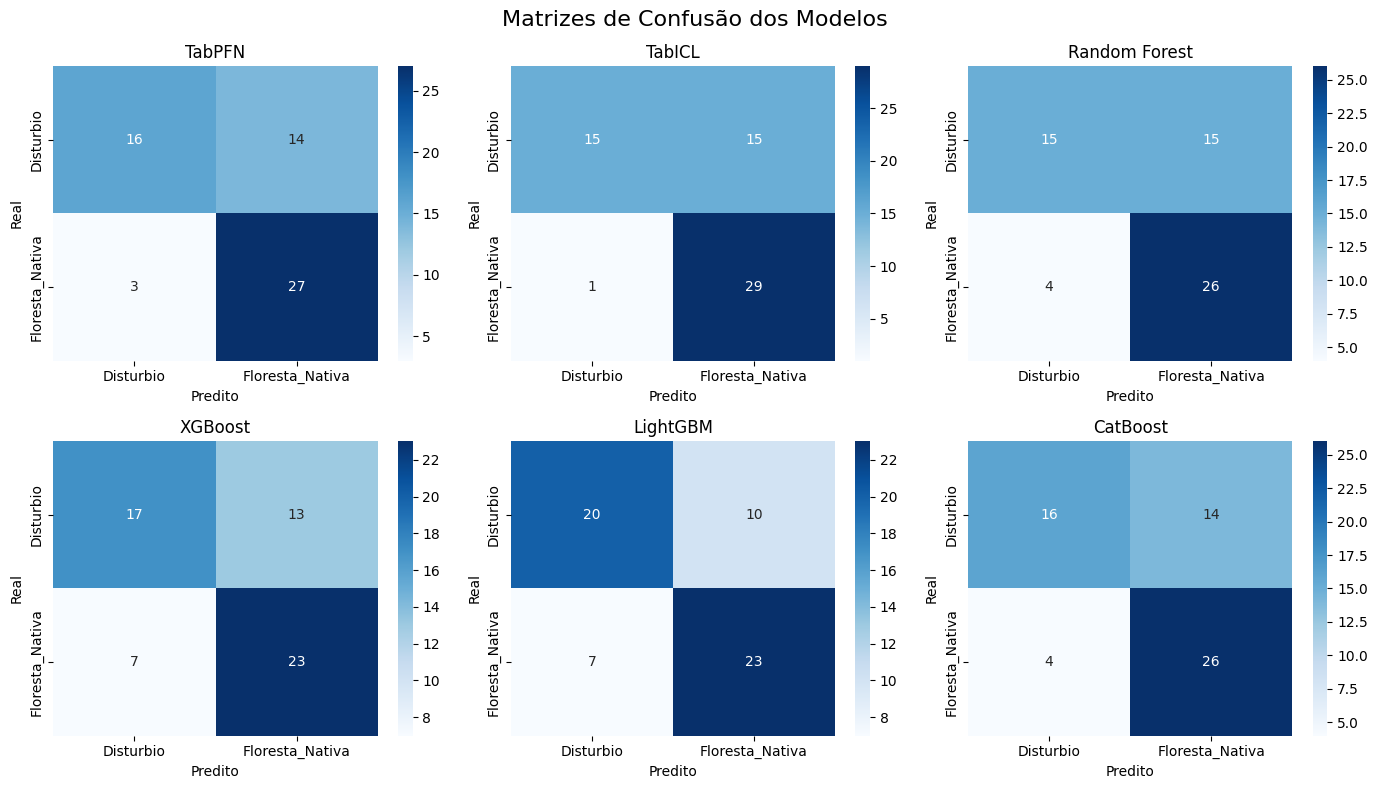

In [20]:
# Classes originais
classes = le.classes_

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8)
)

axes = axes.flatten()

for ax, (nome, pred) in zip(axes, predicoes.items()):

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes,
        ax=ax
    )

    ax.set_title(nome)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.suptitle(
    'Matrizes de Confusão dos Modelos',
    fontsize=16
)

plt.tight_layout()
plt.show()

Métricas

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

resultados = []

for nome, pred in predicoes.items():

    resultados.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1-score': f1_score(y_test, pred, zero_division=0)
    })

df_resultados = pd.DataFrame(resultados)

# Ordenar pelo F1
df_resultados = df_resultados.sort_values(
    by='F1-score',
    ascending=False
).reset_index(drop=True)

print(df_resultados)

          Modelo  Accuracy  Precision    Recall  F1-score
0         TabICL  0.733333   0.659091  0.966667  0.783784
1         TabPFN  0.716667   0.658537  0.900000  0.760563
2       CatBoost  0.700000   0.650000  0.866667  0.742857
3  Random Forest  0.683333   0.634146  0.866667  0.732394
4       LightGBM  0.716667   0.696970  0.766667  0.730159
5       Ensemble  0.683333   0.641026  0.833333  0.724638
6        XGBoost  0.666667   0.638889  0.766667  0.696970


Tempo de treinamento, tempo de inferência e memória

In [22]:
modelos = [
    "TabPFN",
    "TabICL",
    "XGBoost",
    "Random Forest",
    "LightGBM",
    "CatBoost",
    "Ensemble"
]

dados_custos = []

for modelo in modelos:

    dados_custos.append({
        "Modelo": modelo,
        "Tempo_ajuste_s": tempos_ajuste.get(modelo, np.nan),
        "Tempo_inferencia_s": tempos_inferencia.get(modelo, np.nan),
        "Memoria_MB": memorias.get(modelo, np.nan)
    })

df_custos = pd.DataFrame(dados_custos)

print(df_custos)

          Modelo  Tempo_ajuste_s  Tempo_inferencia_s  Memoria_MB
0         TabPFN        0.519541           49.739465   61.078125
1         TabICL        1.255518           12.206271  182.242188
2        XGBoost        0.234207            0.011510    5.667969
3  Random Forest        0.297812            0.084182    1.179688
4       LightGBM        0.057867            0.007029    3.296875
5       CatBoost        1.217262            0.004171   12.960938
6       Ensemble             NaN            0.000285         NaN


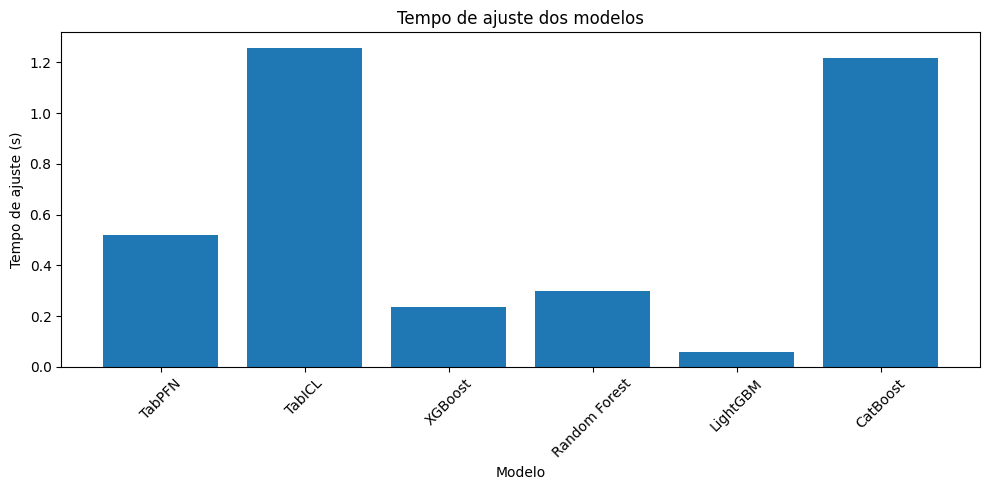

In [23]:
df_tempo_ajuste = df_custos.dropna(
    subset=["Tempo_ajuste_s"]
)

plt.figure(figsize=(10, 5))

plt.bar(
    df_tempo_ajuste["Modelo"],
    df_tempo_ajuste["Tempo_ajuste_s"]
)

plt.ylabel("Tempo de ajuste (s)")
plt.xlabel("Modelo")
plt.title("Tempo de ajuste dos modelos")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

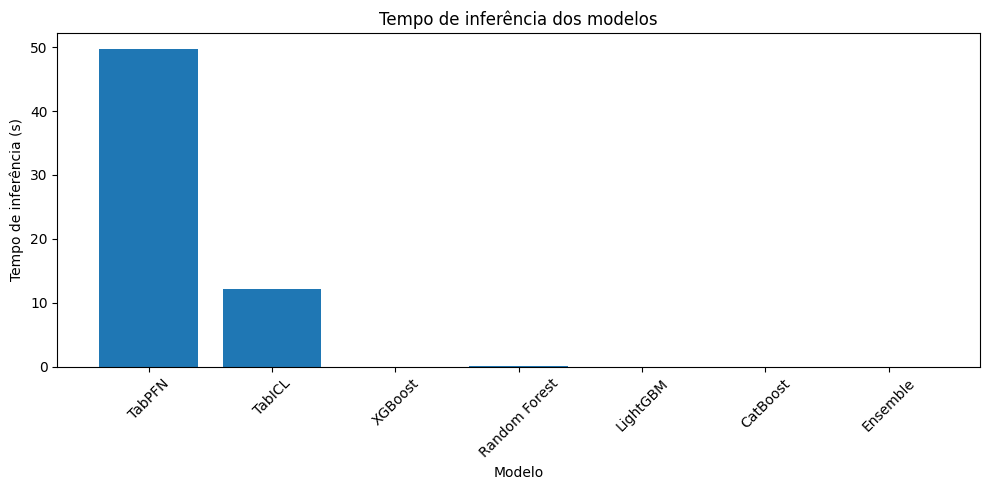

In [24]:
df_tempo_inferencia = df_custos.dropna(
    subset=["Tempo_inferencia_s"]
)

plt.figure(figsize=(10, 5))

plt.bar(
    df_tempo_inferencia["Modelo"],
    df_tempo_inferencia["Tempo_inferencia_s"]
)

plt.ylabel("Tempo de inferência (s)")
plt.xlabel("Modelo")
plt.title("Tempo de inferência dos modelos")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

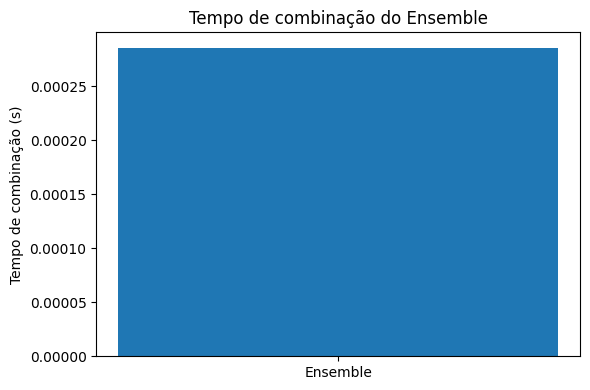

In [25]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Ensemble"],
    [tempo_ensemble]
)

plt.ylabel("Tempo de combinação (s)")
plt.title("Tempo de combinação do Ensemble")

plt.tight_layout()
plt.show()

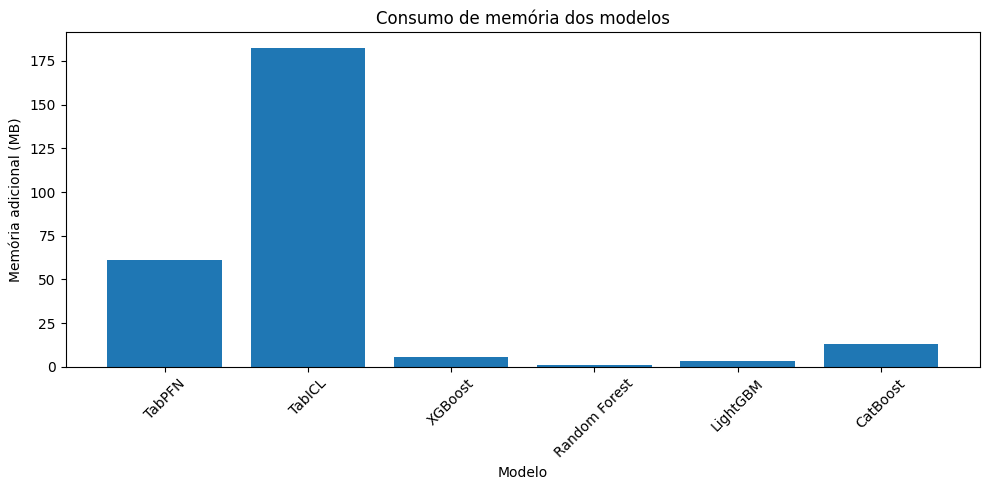

In [26]:
df_memoria = df_custos.dropna(
    subset=["Memoria_MB"]
)

plt.figure(figsize=(10, 5))

plt.bar(
    df_memoria["Modelo"],
    df_memoria["Memoria_MB"]
)

plt.ylabel("Memória adicional (MB)")
plt.xlabel("Modelo")
plt.title("Consumo de memória dos modelos")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sensibilidade ao tamanho do conjunto de treinamento

In [27]:
X_train_sens, X_test_sens, y_train_sens, y_test_sens = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

In [28]:
from sklearn.base import clone
from sklearn.metrics import f1_score
#import time

tamanhos = [0.20, 0.40, 0.60, 0.80, 1.00]

resultados_sensibilidade = []

Treinamento com 28 amostras (20%)
Treinando TabPFN...
  F1: 0.6296 | Acurácia: 0.6667 | Treino: 0.30s
Treinando TabICL...
  F1: 0.7647 | Acurácia: 0.7333 | Treino: 0.52s
Treinando Random Forest...
  F1: 0.7143 | Acurácia: 0.6667 | Treino: 0.25s
Treinando XGBoost...
  F1: 0.5357 | Acurácia: 0.5667 | Treino: 0.07s
Treinando LightGBM...
  F1: 0.6667 | Acurácia: 0.5000 | Treino: 0.02s
Treinando CatBoost...
  F1: 0.6471 | Acurácia: 0.6000 | Treino: 0.41s
  Ensemble | F1: 0.6866 | Acurácia: 0.6500
Treinamento com 56 amostras (40%)
Treinando TabPFN...
  F1: 0.7179 | Acurácia: 0.6333 | Treino: 0.27s
Treinando TabICL...
  F1: 0.7532 | Acurácia: 0.6833 | Treino: 0.74s
Treinando Random Forest...
  F1: 0.7532 | Acurácia: 0.6833 | Treino: 0.24s
Treinando XGBoost...
  F1: 0.7536 | Acurácia: 0.7167 | Treino: 0.12s
Treinando LightGBM...
  F1: 0.7246 | Acurácia: 0.6833 | Treino: 0.03s
Treinando CatBoost...
  F1: 0.6761 | Acurácia: 0.6167 | Treino: 0.54s
  Ensemble | F1: 0.7105 | Acurácia: 0.6333
Treina

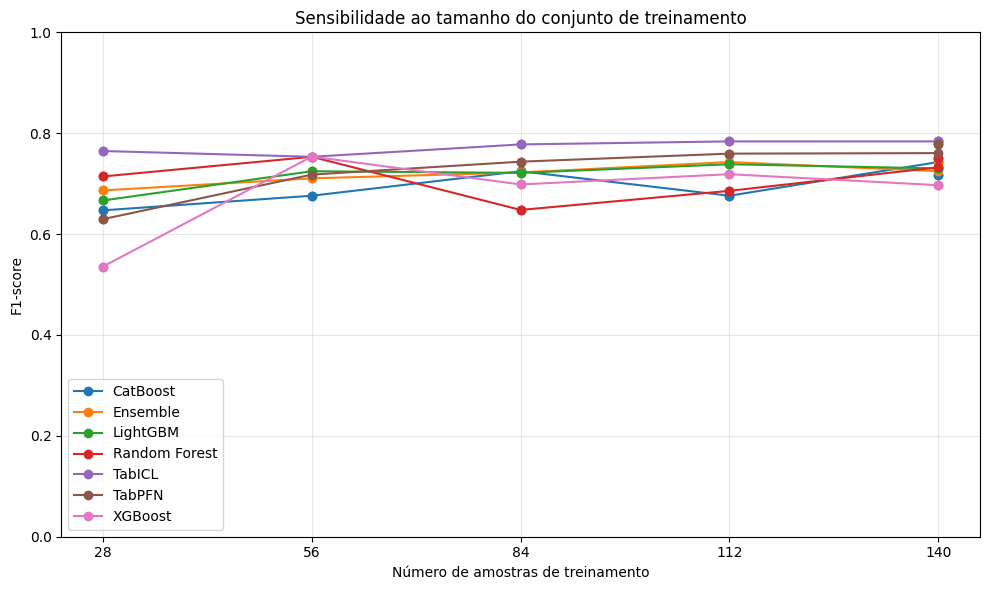

In [38]:
for proporcao in tamanhos:
    n_amostras = int(len(X_train_sens) * proporcao)

    # Embaralhar o conjunto de treinamento
    rng = np.random.RandomState(42)
    indices = rng.permutation(len(X_train_sens))[:n_amostras]
    X_sub = X_train_sens.iloc[indices]

    # Se y_train_sens for Series
    if hasattr(y_train_sens, "iloc"):
        y_sub = y_train_sens.iloc[indices]
    else:
        y_sub = y_train_sens[indices]

    print(f"Treinamento com {n_amostras} amostras ({proporcao*100:.0f}%)")

    #Criar os modelos
    modelos_sens = {

        "TabPFN": TabPFNClassifier(
            model_path="tabpfn-v2-classifier.ckpt",
            device="cpu"
        ),

        "TabICL": TabICLClassifier(
            device="cpu"
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),

        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        ),

        "LightGBM": LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ),

        "CatBoost": CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            random_seed=42,
            verbose=False
        )
    }

    # Treinar e avaliar cada modelo
    probabilidades_sens = {}

    for nome, modelo in modelos_sens.items():

        print(f"Treinando {nome}...")
        inicio = time.perf_counter()
        modelo.fit(X_sub, y_sub)
        tempo_ajuste = time.perf_counter() - inicio

        # Inferência
        inicio = time.perf_counter()

        pred = modelo.predict(X_test_sens)
        prob = modelo.predict_proba(X_test_sens)

        tempo_inferencia = time.perf_counter() - inicio

        # Métricas
        f1 = f1_score(
            y_test_sens,
            pred,
            zero_division=0
        )

        acuracia = accuracy_score(
            y_test_sens,
            pred
        )

        # Guardar probabilidades
        probabilidades_sens[nome] = prob

        # Resultados
        resultados_sensibilidade.append({
            "Modelo": nome,
            "Proporcao_treinamento": proporcao,
            "Amostras_treinamento": n_amostras,
            "F1-score": f1,
            "Acuracia": acuracia,
            "Tempo_ajuste_s": tempo_ajuste,
            "Tempo_inferencia_s": tempo_inferencia
        })


        print(
            f"  F1: {f1:.4f} | "
            f"Acurácia: {acuracia:.4f} | "
            f"Treino: {tempo_ajuste:.2f}s"
        )

    #Ensemble
    probabilidades_classe_1 = np.column_stack([
        probabilidades_sens["TabPFN"][:, 1],
        probabilidades_sens["TabICL"][:, 1],
        probabilidades_sens["XGBoost"][:, 1],
        probabilidades_sens["Random Forest"][:, 1],
        probabilidades_sens["LightGBM"][:, 1],
        probabilidades_sens["CatBoost"][:, 1]
    ])


    # Combinação das probabilidades
    inicio = time.perf_counter()

    prob_ensemble_sens = probabilidades_classe_1.mean(axis=1)

    pred_ensemble_sens = (
        prob_ensemble_sens >= 0.5
    ).astype(int)

    tempo_combinacao = time.perf_counter() - inicio


    # Métricas do Ensemble
    f1_ensemble = f1_score(
        y_test_sens,
        pred_ensemble_sens,
        zero_division=0
    )

    acuracia_ensemble = accuracy_score(
        y_test_sens,
        pred_ensemble_sens
    )

    # Resultado do Ensemble
    resultados_sensibilidade.append({

        "Modelo": "Ensemble",

        "Proporcao_treinamento": proporcao,

        "Amostras_treinamento": n_amostras,

        "F1-score": f1_ensemble,

        "Acuracia": acuracia_ensemble,

        "Tempo_ajuste_s": np.nan,

        "Tempo_inferencia_s": np.nan,

        "Tempo_combinacao_s": tempo_combinacao

    })

    print(
        f"  Ensemble | "
        f"F1: {f1_ensemble:.4f} | "
        f"Acurácia: {acuracia_ensemble:.4f}"
    )

#Resultados
df_sensibilidade = pd.DataFrame(
    resultados_sensibilidade
)

# Ordenar
df_sensibilidade = df_sensibilidade.sort_values(
    ["Modelo", "Proporcao_treinamento"]
)
print("\n")
print(df_sensibilidade)

#Gráfico de sensibilidade ao tamanho do treinamento

plt.figure(figsize=(10, 6))

for modelo in df_sensibilidade["Modelo"].unique():

    dados = df_sensibilidade[
        df_sensibilidade["Modelo"] == modelo
    ]

    plt.plot(
        dados["Amostras_treinamento"],
        dados["F1-score"],
        marker="o",
        label=modelo
    )


plt.xlabel("Número de amostras de treinamento")

plt.ylabel("F1-score")

plt.title(
    "Sensibilidade ao tamanho do conjunto de treinamento"
)

plt.xticks(
    sorted(
        df_sensibilidade["Amostras_treinamento"].unique()
    )
)

plt.ylim(0, 1)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()